In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def get_stock_data(ticker, period="3mo"):
    stock = yf.Ticker(ticker)
    data = stock.history(period=period)
    data = data[["Open", "High", "Low", "Close", "Volume"]]
    data.index = data.index.tz_localize(None)
    return data

# Test it
df = get_stock_data("AAPL", period="3mo")
print(df.shape)
print(df.head())

(62, 5)
                  Open        High         Low       Close    Volume
Date                                                                
2026-02-02  259.786917  270.237131  258.967677  269.757599  73913400
2026-02-03  268.948351  271.625839  267.359811  269.228088  64394700
2026-02-04  272.035451  278.689229  272.035451  276.231506  90545700
2026-02-05  277.869995  279.238709  272.974582  275.652069  52977400
2026-02-06  276.860920  280.647386  276.671095  277.859985  50453400


In [3]:
def calculate_returns(df):
    df = df.copy()
    df["Daily_Return"] = df["Close"].pct_change()
    df["Return_%"] = df["Daily_Return"] * 100
    return df

df = calculate_returns(df)
print(df[["Close", "Daily_Return", "Return_%"]].tail(10))

                 Close  Daily_Return  Return_%
Date                                          
2026-04-17  270.230011      0.025930  2.593021
2026-04-20  273.049988      0.010435  1.043547
2026-04-21  266.170013     -0.025197 -2.519676
2026-04-22  273.170013      0.026299  2.629898
2026-04-23  273.429993      0.000952  0.095171
2026-04-24  271.059998     -0.008668 -0.866765
2026-04-27  267.609985     -0.012728 -1.272785
2026-04-28  270.709991      0.011584  1.158404
2026-04-29  270.170013     -0.001995 -0.199467
2026-04-30  271.350006      0.004368  0.436759


In [4]:
def detect_anomalies(df, threshold=2.0):
    df = df.copy()
    
    # Calculate mean and standard deviation of returns
    mean_return = df["Daily_Return"].mean()
    std_return = df["Daily_Return"].std()
    
    # Calculate Z-Score for each day
    df["Z_Score"] = (df["Daily_Return"] - mean_return) / std_return
    
    # Flag anomalies where Z-Score exceeds threshold
    df["Is_Anomaly"] = df["Z_Score"].abs() > threshold
    
    anomalies = df[df["Is_Anomaly"] == True]
    
    print(f"Mean Daily Return: {mean_return:.4f}")
    print(f"Std Daily Return: {std_return:.4f}")
    print(f"\nAnomalies Detected: {len(anomalies)}")
    print("\nAnomaly Dates:")
    print(anomalies[["Close", "Return_%", "Z_Score"]])
    
    return df, anomalies

df, anomalies = detect_anomalies(df)

Mean Daily Return: 0.0002
Std Daily Return: 0.0157

Anomalies Detected: 3

Anomaly Dates:
                 Close  Return_%   Z_Score
Date                                      
2026-02-12  261.730011 -4.998181 -3.204085
2026-02-17  263.880005  3.166786  2.007377
2026-02-27  264.179993 -3.213050 -2.064687


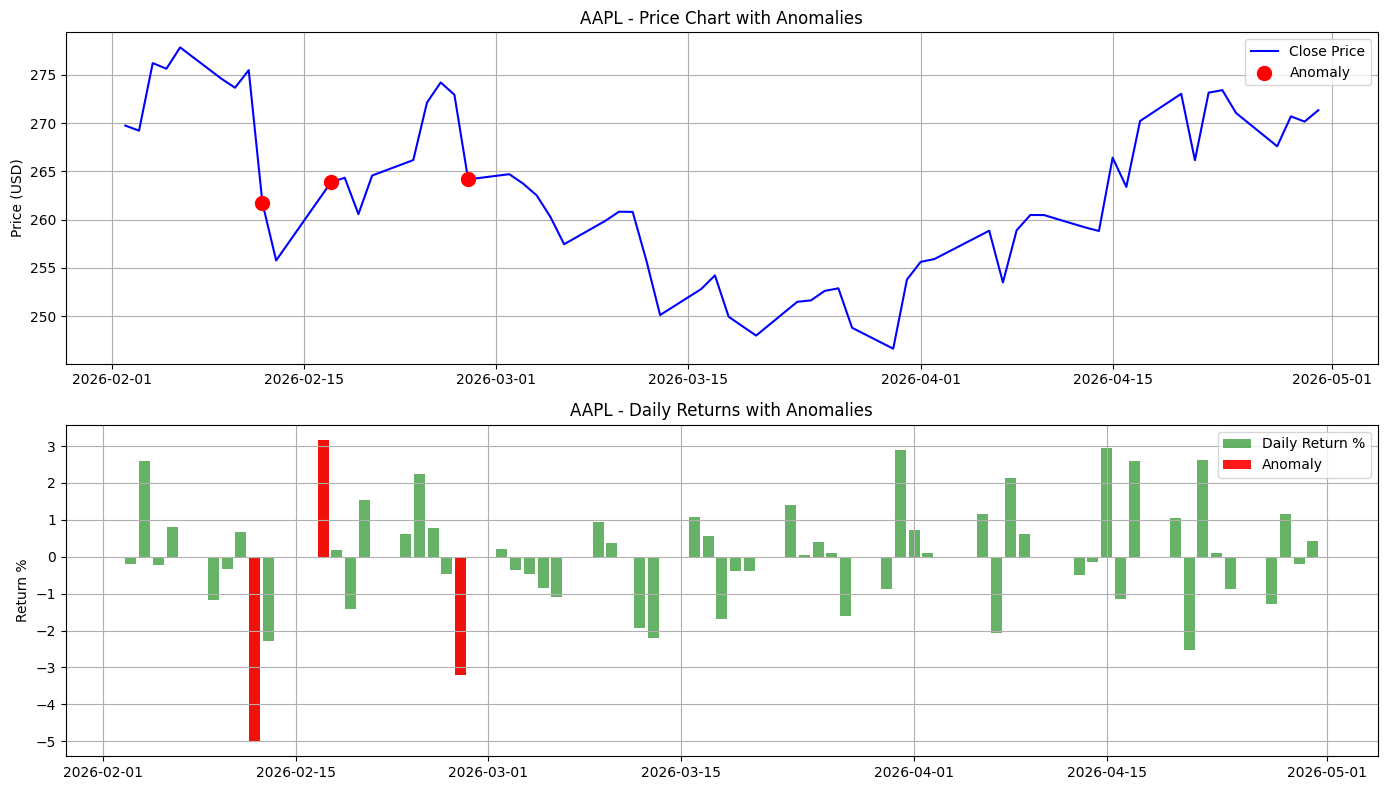

In [5]:
def plot_anomalies(df, ticker):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Plot 1 — Price chart with anomalies marked
    ax1.plot(df.index, df["Close"], color="blue", linewidth=1.5, label="Close Price")
    anomalies = df[df["Is_Anomaly"] == True]
    ax1.scatter(anomalies.index, anomalies["Close"], 
                color="red", s=100, zorder=5, label="Anomaly")
    ax1.set_title(f"{ticker} - Price Chart with Anomalies")
    ax1.set_ylabel("Price (USD)")
    ax1.legend()
    ax1.grid(True)
    
    # Plot 2 — Daily returns with anomalies marked
    ax2.bar(df.index, df["Return_%"], color="green", alpha=0.6, label="Daily Return %")
    ax2.bar(anomalies.index, anomalies["Return_%"], color="red", alpha=0.9, label="Anomaly")
    ax2.set_title(f"{ticker} - Daily Returns with Anomalies")
    ax2.set_ylabel("Return %")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_anomalies(df, "AAPL")

Mean Daily Return: 0.0090
Std Daily Return: 0.0267

Anomalies Detected: 4

Anomaly Dates:
                 Close  Return_%   Z_Score
Date                                      
2026-02-03  143.619995  6.701329  2.170596
2026-02-04  155.289993  8.125608  2.703478
2026-02-13  139.899994 -6.602577 -2.806950
2026-03-12  149.110001  7.389265  2.427981


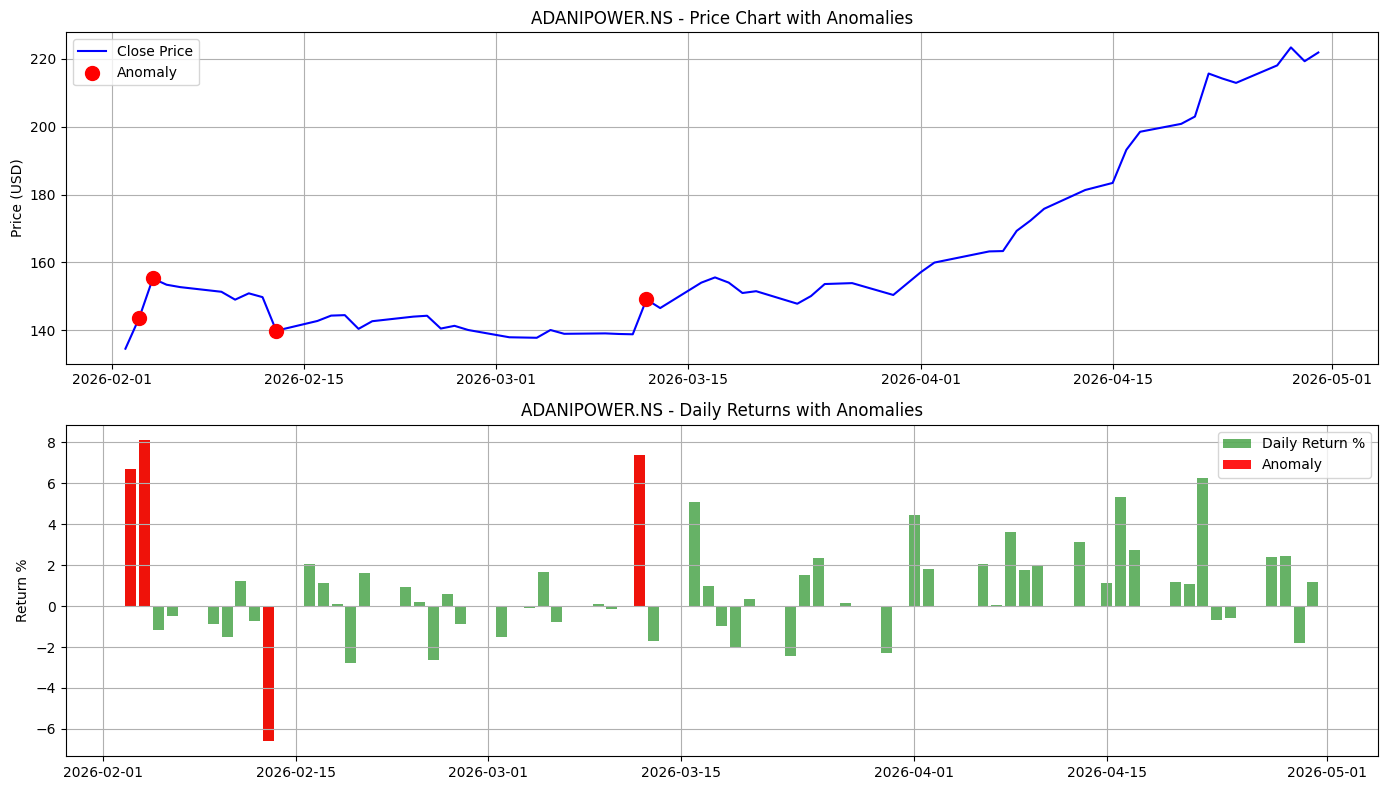

In [6]:
df_adani = get_stock_data("ADANIPOWER.NS", period="3mo")
df_adani = calculate_returns(df_adani)
df_adani, anomalies_adani = detect_anomalies(df_adani)
plot_anomalies(df_adani, "ADANIPOWER.NS")